<a href="https://colab.research.google.com/github/rendifikri14/UTS_VisiKomputer_23423020_RendiFikriA/blob/main/UTS_VisiKomputer_23423020_RendiFikriA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 2013-05-06_17_29_22_Stream_and_forest_along_Turkey_Top_Road_in_northern_Lebanon_Township_in_Hunterdon_County,_New_Jersey.jpg to 2013-05-06_17_29_22_Stream_and_forest_along_Turkey_Top_Road_in_northern_Lebanon_Township_in_Hunterdon_County,_New_Jersey.jpg


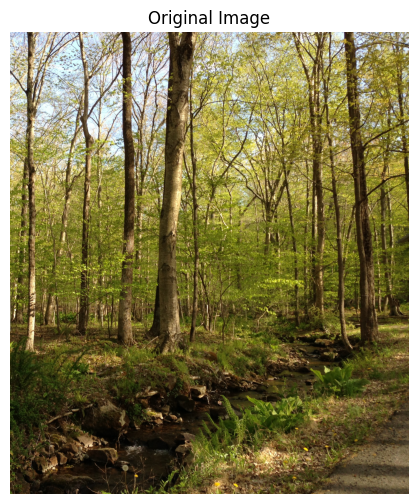

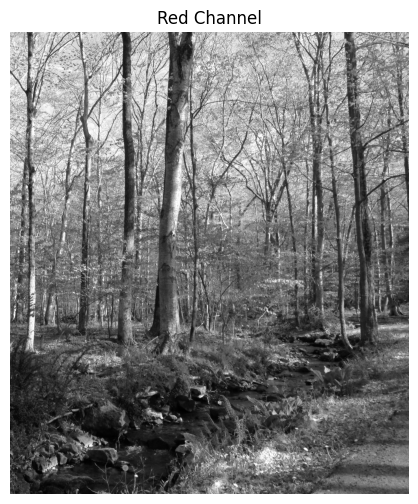

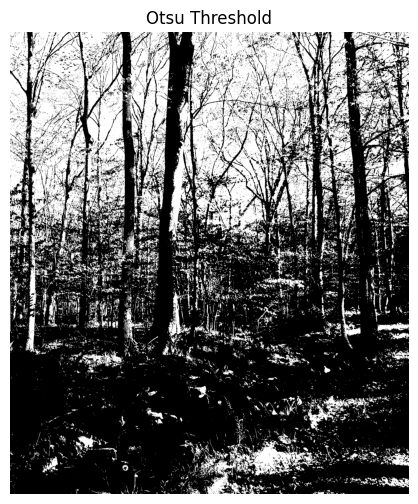

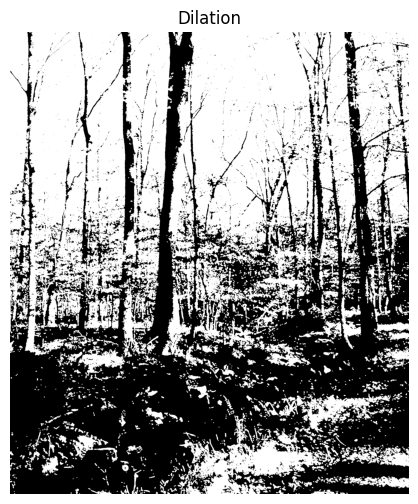

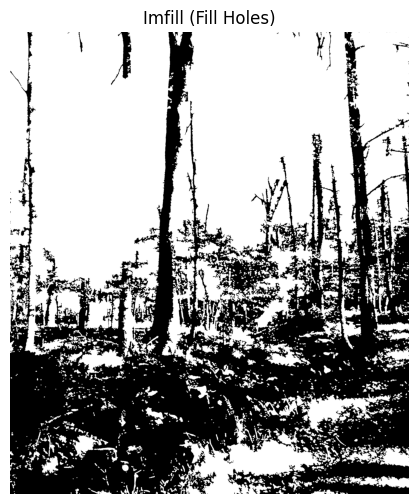

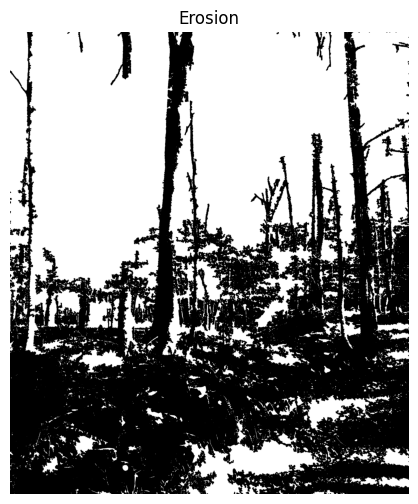

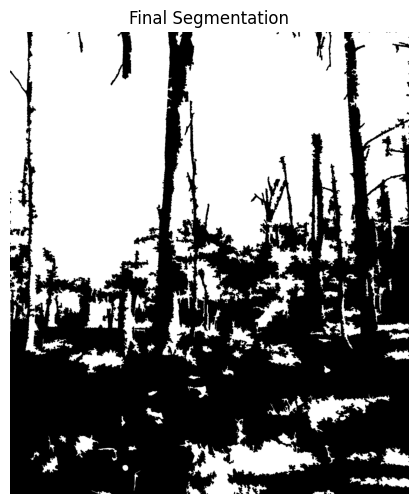

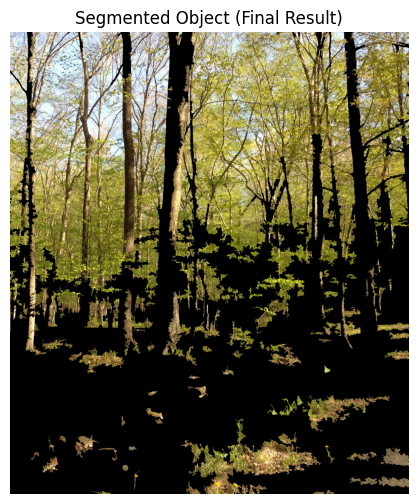

In [6]:
# ==============================
# INSTALL LIBRARY
# ==============================
!pip install opencv-python matplotlib scikit-image

# ==============================
# IMPORT LIBRARY
# ==============================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from google.colab import files

# ==============================
# UPLOAD GAMBAR
# ==============================
uploaded = files.upload()

# Ambil nama file
file_name = list(uploaded.keys())[0]

# Baca gambar
img = cv2.imread(file_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==============================
# STEP 1: TAMPILKAN GAMBAR ASLI
# ==============================
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

# ==============================
# STEP 2: RED CHANNEL EXTRACTION
# ==============================
red_channel = img[:,:,0]

plt.figure(figsize=(6,6))
plt.imshow(red_channel, cmap='gray')
plt.title("Red Channel")
plt.axis('off')
plt.show()

# ==============================
# STEP 3: OTSU THRESHOLDING
# ==============================
_, otsu = cv2.threshold(red_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.imshow(otsu, cmap='gray')
plt.title("Otsu Threshold")
plt.axis('off')
plt.show()

# ==============================
# STEP 4: MORPHOLOGICAL OPERATIONS
# ==============================

# Kernel (disk/ellipse 5x5 sesuai paper)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

# --- DILATION ---
dilation = cv2.dilate(otsu, kernel, iterations=1)

plt.figure(figsize=(6,6))
plt.imshow(dilation, cmap='gray')
plt.title("Dilation")
plt.axis('off')
plt.show()

# --- IMFILL (FILL HOLES) ---
imfill = binary_fill_holes(dilation).astype(np.uint8)*255

plt.figure(figsize=(6,6))
plt.imshow(imfill, cmap='gray')
plt.title("Imfill (Fill Holes)")
plt.axis('off')
plt.show()

# --- EROSION ---
erosion = cv2.erode(imfill, kernel, iterations=1)

plt.figure(figsize=(6,6))
plt.imshow(erosion, cmap='gray')
plt.title("Erosion")
plt.axis('off')
plt.show()

# --- REMOVE SMALL OBJECTS (BWAREAOPEN) ---
clean = remove_small_objects(erosion.astype(bool), min_size=500)
clean = clean.astype(np.uint8)*255

plt.figure(figsize=(6,6))
plt.imshow(clean, cmap='gray')
plt.title("Final Segmentation")
plt.axis('off')
plt.show()

# ==============================
# STEP 5: OVERLAY HASIL KE GAMBAR ASLI
# ==============================
# Masking hasil ke gambar asli
result = cv2.bitwise_and(img, img, mask=clean)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Segmented Object (Final Result)")
plt.axis('off')
plt.show()